李佩瑶 22300180089

实验记录在我的[github](https://github.com/5697526/MNIST-Handwritten-Digit-Classification.git)

数据集来自[MNIST](https://pan.baidu.com/s/17M_K2HSsItxeKJOBSzPdQA?pwd=dpxb) 提取码: dpxb

## 一、实验目的

本次实验基于 MNIST 手写数字数据集开展，旨在通过搭建和优化神经网络模型，实现对手写数字的准确分类。需要实现一个或多个神经网络来识别手写数字，并进行实验来测试模型并得出模型的能力。之后，从几个方面对模型进行修改，并测试模型是否表现更好。

## 二、数据集介绍

### 1. 数据来源

MNIST 数据集由美国国家标准与技术研究院（NIST）原始数据集重新整合而来。原始 NIST 数据包含不同人群书写的数字样本，MNIST 通过 “重新混合” 这些样本，构建出一个更具代表性的手写数字数据库，为模型训练提供了丰富多样的数据基础。

### 2. 数据集内容

MNIST 数据集由 60,000 张训练图像和 10,000 张测试图像组成。数据集中每张图像均为 28×28 像素的手写数字 (0-9) 灰度图。

### 3. 数据格式与存储

数据集以二进制形式存储。每个图像在存储时，28×28 的像素值被按顺序排列成一个 784（28×28）维的向量。标签数据则以简单的数字编码形式存储，对应 0 - 9 的数字类别。

## 三、基础模型实现

### 1. 多层感知机(MLP)：

Model_MLP 类继承自 Layer 类，用于构建一个多层感知机模型。此部分代码已给出。

`__init__(self, size_list=None, act_func=None)`初始化 MLP 模型。初始化 size_list、act_func 和 dropout_layers。遍历 size_list，创建线性层 Linear。根据 act_func 的值，创建 ReLU 激活函数层 ReLU。将线性层和激活函数层添加到 layers 列表中。

In [8]:
def __init__(self, size_list=None, act_func=None):
    self.size_list = size_list
    self.act_func = act_func
    self.dropout_layers = []
    if size_list is not None and act_func is not None:
        self.layers = []
        for i in range(len(size_list) - 1):
            layer = Linear(in_dim=size_list[i], out_dim=size_list[i + 1])
            if act_func == 'Logistic':
                raise NotImplementedError
            elif act_func == 'ReLU':
                layer_f = ReLU()
            self.layers.append(layer)
            if i < len(size_list) - 2:
                self.layers.append(layer_f)

`__call__(self, X)`使得可以直接调用模型实例进行前向传播。

`forward(self, X)`实现模型的前向传播,将输入数据通过 layers 列表中的每一层，得到输出结果。

`backward(self, loss_grad)`实现模型的反向传播，从后往前遍历 layers 列表，依次调用每一层的 backward 方法，将梯度反向传播回去。

`load_model(self, param_list)`从文件中加载模型的参数。

`save_model(self, save_path)`将模型的参数保存到文件中。

### 2. 基础模型实验

#### (1) 基础代码补全

在`op.py` 中补全继承自 Layer 类的 Linear 类，即神经网络中的线性层（全连接层）。

`forward(self, X)`前向传播方法接收输入 X，将输入 X 与权重 W 进行矩阵乘法，并加上偏置 b，得到输出 output，同时，将输入 X 存储在 self.input 中，以便在反向传播时使用。

In [ ]:
def forward(self, X):
    self.input = X
    output = np.dot(X, self.W) + self.b
    return output

`backward(self, grad: np.ndarray)`反向传播方法接收来自下一层的梯度 grad，首先通过输入 self.input 的转置与 grad 进行矩阵乘法得到权重 W 的梯度。然后将 grad 按行求和并保持维度得到偏置 b 的梯度。最后，计算需要传递给上一层的梯度 input_grad，通过 grad 与权重 W 的转置进行矩阵乘法得到。

In [ ]:
def backward(self, grad: np.ndarray):
    self.grads['W'] = np.dot(self.input.T, grad)
    if self.weight_decay:
        self.grads['W'] += self.weight_decay_lambda * self.W
    self.grads['b'] = np.sum(grad, axis=0, keepdims=True)
    input_grad = np.dot(grad, self.W.T)
    return input_grad

在`op.py`中补全MultiCrossEntropyLoss类，提供前向传播和反向传播的功能。

`forward(self, predicts, labels)`前向传播方法接收预测的概率分布 predicts 和真实标签 labels 作为输入，对预测概率进行裁剪，避免出现 log(0) 的情况。提取每个样本正确类别的预测概率，计算每个样本的负对数损失，并求平均值得到最终的交叉熵损失。

In [ ]:
def forward(self, predicts, labels):
    self.labels = labels
    self.probs = np.clip(predicts, 1e-15, 1 - 1e-15)
    batch_size = predicts.shape[0]
    correct_probs = self.probs[np.arange(batch_size), labels]
    loss = -np.mean(np.log(correct_probs))
    return loss

`backward(self)`反向传播方法计算损失关于预测概率的梯度。创建一个与预测概率形状相同的 one - hot 矩阵，将真实标签对应的位置设为 1，计算梯度 grads。

In [ ]:
def backward(self):
    batch_size = self.probs.shape[0]
    one_hot = np.zeros_like(self.probs)
    one_hot[np.arange(batch_size), self.labels] = 1
    grads = (self.probs - one_hot) / batch_size
    return grads

#### (2) 基础模型训练

调整参数为：n_hidden=[128]，learning_rate=0.001。用`test_train.py`对基础模型进行训练，将训练结果保存于 './best_models/best_model_0'，将训练过程保存于 './training_logs/training_log_0'。再用`test_model.py`进行模型的测试。

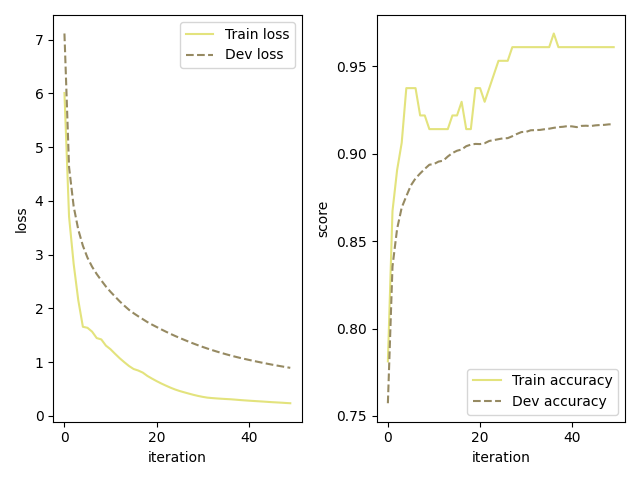

训练时的验证准确率为0.9168，测试准确率为0.818，说明模型能够从训练数据中学习到手写数字的特征和模式，进而对训练集中的大部分样本进行正确分类，但仍有较大提升空间。

## 四、模型改进实验

### 1. Change the network structure: the vector nHidden specifies the number of hidden units in each layer.

通过修改 Model_MLP 类的 size_list 参数，可以改变网络的结构，指定每个隐藏层的神经元数量。

调整参数为：n_hidden=[256, 128]，learning_rate=0.001。用`test_train.py`对模型进行训练，再用`test_model.py`进行模型的测试。训练结果保存于 './best_models/best_model_1'，训练过程保存于 './training_logs/training_log_1'。

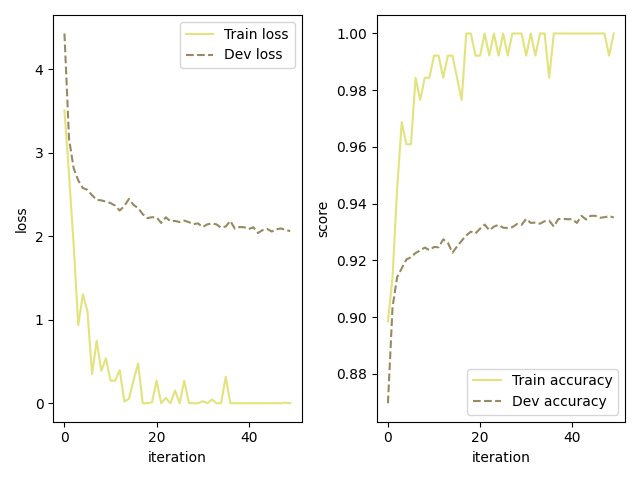

训练模型时验证准确率达到了0.9357，但是测试准确率只有0.8134。从训练图中也不难看出，模型有比较严重的过拟合，有待改进。

### 2. Change the training procedure by modifying the sequence of step-sizes or using different step-sizes for different variables.

引入动量项来更新权重，公式为：$w_{t+1} = w_{t} - \alpha_{t} \nabla f(w_{t}) + \beta_{t} (w_{t} - w_{t-1})$，其中$\alpha_{t}$是学习率，$\beta_{t}$是动量强度（通常取 0.9）。

#### (1)在`optimizer.py`里实现 MomentGD 优化器

MomentGD 类是一个增强版的动量梯度下降优化器，继承自 Optimizer 类。它在传统动量梯度下降的基础上，增加了一些特性，包括支持特定层的学习率、Nesterov 加速梯度选项以及更好的权重衰减处理。

`__init__(self, init_lr, model, mu=0.9, layer_specific_lr=None, nesterov=False)`调用父类 Optimizer 的初始化方法，传入基础学习率和模型。保存动量系数 mu、Nesterov 标志和特定层学习率字典，遍历模型的所有层，对于具有 grads 属性的层（即可更新的层），初始化 velocities 字典，用于存储每个可更新层的动量信息。初始化其动量信息，并将层的索引和层对象添加到 layer_map 列表中。

In [ ]:
def __init__(self, init_lr, model, mu=0.9, layer_specific_lr=None, nesterov=False):
    super().__init__(init_lr, model)
    self.mu = mu
    self.nesterov = nesterov
    self.layer_specific_lr = layer_specific_lr or {}
    self.velocities = {}

    self.layer_map = []
    layer_idx = 0
    for i, layer in enumerate(self.model.layers):
        if hasattr(layer, 'grads'):
            self.velocities[layer] = {
                key: np.zeros_like(layer.params[key])
                for key in layer.params.keys()
            }
            self.layer_map.append((i, layer))
            layer_idx += 1

`step(self)`优化步骤方法遍历可更新层，获取其对应的索引和层对象。根据基础学习率和特定层学习率乘数，计算当前层的学习率。对每个参数的梯度进行裁剪，防止梯度爆炸。如果 nesterov 标志为 True，则先对参数进行一个预更新，然后计算梯度，最后再将参数恢复到原来的位置。如果当前层支持权重衰减，并且当前参数是权重矩阵 W，则在梯度中加入权重衰减项。根据动量更新公式更新动量信息和参数。

In [ ]:
def step(self):
    for layer_idx, (model_idx, layer) in enumerate(self.layer_map):
        if hasattr(layer, 'grads'):
            lr = self.init_lr * self.layer_specific_lr.get(layer_idx, 1.0)

            for key in layer.params.keys():
                if layer.grads[key] is not None:
                    max_grad = 1.0
                    layer.grads[key] = np.clip(
                        layer.grads[key], -max_grad, max_grad)

                    if self.nesterov:
                        layer.params[key] += self.mu * self.velocities[layer][key]

                        grad = layer.grads[key]

                        layer.params[key] -= self.mu * self.velocities[layer][key]
                    else:
                        grad = layer.grads[key]

                    if hasattr(layer, 'weight_decay') and layer.weight_decay and key == 'W':
                        grad += layer.weight_decay_lambda * layer.params[key]

                    self.velocities[layer][key] = (
                        self.mu * self.velocities[layer][key] -
                        lr * grad
                    )

                    layer.params[key] += self.velocities[layer][key]

#### (2) 在`lr_scheduler.py`里实现 MultiStepLR 学习率调度器

MultiStepLR 类继承自 scheduler 类，其主要功能是在训练过程中的特定轮次对优化器的学习率进行衰减。

`__init__(self, optimizer, milestones=[30, 60, 90], gamma=0.1)`调用父类 scheduler 的初始化方法，将传入的 optimizer 传递给父类进行初始化，保存 milestones 和 gamma 到类的属性中，以便后续使用。初始化 last_milestone 为 0，用于记录已经达到的最后一个里程碑的索引。

In [ ]:
def __init__(self, optimizer, milestones=[30, 60, 90], gamma=0.1) -> None:
    super().__init__(optimizer)
    self.milestones = milestones
    self.gamma = gamma
    self.last_milestone = 0  # Track the last milestone reached

`step(self)`学习率更新方法更新训练轮次计数,从 last_milestone 开始遍历 milestones 列表，对于每个里程碑，如果当前训练轮次 step_count 大于或等于该里程碑，则将优化器的初始学习率 init_lr 乘以 gamma，实现学习率的衰减,并且将 last_milestone 加 1，表示已经越过了这个里程碑，后续不会再对该里程碑进行检查。

In [ ]:
def step(self) -> None:
    self.step_count += 1
    for milestone in self.milestones[self.last_milestone:]:
        if self.step_count >= milestone:
            self.optimizer.init_lr *= self.gamma
            self.last_milestone += 1

#### (3) 改进模型训练

调整参数为：n_hidden=[256, 128]，learning_rate=0.001，use_nesterov=True，momentum=0.9。用`test_train.py`对模型进行训练，再用`test_model.py`进行模型的测试。训练结果保存于 './best_models/best_model_2'，训练过程保存于 './training_logs/training_log_2'。

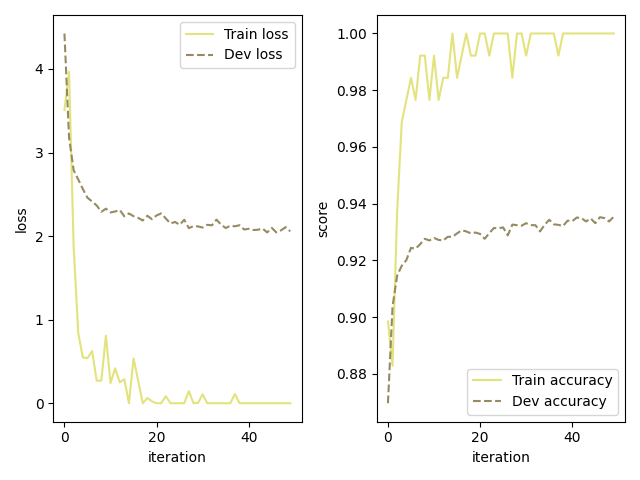

训练模型时验证准确率达到了0.9354，但是测试准确率只有0.8026。说明模型过拟合依然比较严重。但根据图像观测，模型训练得更快且更稳定了，说明动量的方法对模型有改进。

### 3. Try some regularization methods. (Say, l2 regularization, dropout, early stopping or other methods). 

#### (1) L2 Regularization

在`op.py`中定义 L2Regularization 类，用于计算 L2 正则化损失并进行反向传播。

`__init__(self, model, lambda_=1e-4)`初始化方法接收模型 model 和正则化系数 lambda_ 作为参数，将它们保存为类的属性。

In [ ]:
def __init__(self, model, lambda_=1e-4):
    super().__init__()
    self.model = model
    self.lambda_ = lambda_
    self.optimizable = False

`forward(self)`前向传播方法遍历模型的所有层，对于线性层（Linear），计算其权重矩阵 W 的平方和，然后乘以 0.5 * lambda_ 得到 L2 正则化损失。

In [ ]:
def forward(self):
      l2_loss = 0
       for layer in self.model.layers:
            if isinstance(layer, Linear):
                l2_loss += np.sum(np.square(layer.W))
        return 0.5 * self.lambda_ * l2_loss

`backward(self)`反向传播方法遍历模型的所有层，对于线性层（Linear），将 lambda_ * layer.W 加到权重矩阵 W 的梯度 layer.grads['W'] 上。

In [22]:
def backward(self):
    for layer in self.model.layers:
        if isinstance(layer, Linear):
            layer.grads['W'] += self.lambda_ * layer.W

在`runner.py`的 RunnerM 类中使用 L2 正则化，根据 loss_type 和 weight_decay_lambda 的值决定是否使用 L2 正则化。

在 RunnerM 类的初始化方法`__init__(self, model, optimizer, metric, loss_fn, scheduler=None, batch_size=32, loss_type='cross_entropy', weight_decay_lambda=0)`中，如果 loss_type 为 'cross_entropy_with_l2' 且 weight_decay_lambda 大于 0，则创建 L2Regularization 类的实例 self.l2_regularizer。

In [ ]:
def __init__(self, model, optimizer, metric, loss_fn, scheduler=None, batch_size=32, loss_type='cross_entropy', weight_decay_lambda=0):
    # 其余部分省略
    self.loss_type = loss_type
    self.weight_decay_lambda = weight_decay_lambda
    self.l2_regularizer = None
    if self.loss_type == 'cross_entropy_with_l2' and self.weight_decay_lambda > 0:
        self.l2_regularizer = L2Regularization(
            model=model,
            lambda_=self.weight_decay_lambda
        )

在训练方法`train(self, train_data, valid_data, num_epochs, log_iters, save_dir, save_name, augment=False)`中，在每个训练批次中，计算模型的输出 logits 和损失 loss，如果 self.l2_regularizer 存在，则调用其 forward 方法计算 L2 正则化损失，并将其加到总损失 loss 中。在反向传播时，如果 self.l2_regularizer 存在，则调用其 backward 方法更新权重矩阵 W 的梯度。

In [23]:
def train(self, train_data, valid_data, num_epochs, log_iters, save_dir, save_name, augment=False):
    # 其余部分省略
    for epoch in range(num_epochs):
        # 其余部分省略
        for batch_idx in range(num_batches):
            # 其余部分省略
            logits = self.model(batch_X)
            loss = self.loss_fn(logits, batch_y)
            if self.l2_regularizer:
                l2_loss = self.l2_regularizer.forward()
                loss += l2_loss
            score = self.metric(logits, batch_y)

            self.loss_fn.backward()
            if self.l2_regularizer:
                self.l2_regularizer.backward()
            self.optimizer.step()
            # 其余部分省略

#### (2) Dropout

在`op.py`文件里实现Dropout方法。

`__init__(self, p=0.5)`实现Dropout 类的初始化。

In [ ]:
def __init__(self, p=0.5):
    super().__init__()
    self.p = p
    self.mask = None
    self.optimizable = False
    self.training = True

`forward(self, X)`实现前向传播方法，当处于训练模式（self.training 为 True）时借助 np.random.rand(*X.shape) 生成一个与输入 X 形状相同的随机数组，元素取值范围是 [0, 1)，把随机数组中大于 self.p 的元素置为 True，小于等于 self.p 的元素置为 False，以此生成一个布尔掩码。为了保证在训练和测试时输出的期望一致，将布尔掩码除以 (1 - self.p)。把输入 X 与掩码 self.mask 相乘，得到经过 Dropout 处理后的输出。当处于测试模式时，直接返回输入 X。

In [ ]:
def forward(self, X):
    if self.training:
        self.mask = (np.random.rand(*X.shape) > self.p) / (1 - self.p)
        return X * self.mask
    return X

`backward(self, grad)`实现反向传播，当处于训练模式（self.training 为 True）时，将传入的梯度 grad 与掩码 self.mask 相乘，确保在反向传播过程中，被丢弃的神经元对应的梯度为 0。当处于测试模式时直接返回传入的梯度 grad。

In [ ]:
def backward(self, grad):
    return grad * self.mask if self.training else grad

在`models.py`文件的 Model_MLP 类里，可以通过 add_dropout 方法添加 Dropout 层。

dropout_rates是一个列表，每个元素代表对应 Dropout 层的丢弃概率。遍历模型的所有层，在合适的位置添加 Dropout 层，并将这些 Dropout 层存储在 self.dropout_layers 列表中。

In [ ]:
def add_dropout(self, dropout_rates):
    new_layers = []
    for i, layer in enumerate(self.layers):
        new_layers.append(layer)
        if i < len(self.layers) - 1 and i < len(dropout_rates):
            dropout_layer = Dropout(dropout_rates[i])
            new_layers.append(dropout_layer)
            self.dropout_layers.append(dropout_layer)
    self.layers = new_layers

在 Model_MLP 类中，提供了 train 和 eval 方法用于切换训练和测试模式，控制是否使用 Dropout 功能。

In [ ]:
def train(self):
    for layer in self.dropout_layers:
        layer.train()
        
def eval(self):
    for layer in self.dropout_layers:
        layer.eval()

#### (3) Early Stopping

`runner.py`文件里的 EarlyStopping 类实现了早停策略。

`__init__(self, patience=5, min_delta=0)`初始化方法定义了 EarlyStopping 类。patience 表示在验证损失没有显著改善时，允许继续训练的最大轮数，min_delta 表示验证损失需要改善的最小变化量，counter 用于记录验证损失没有显著改善的连续轮数，best_loss 用于记录验证损失的最优值。

In [ ]:
def __init__(self, patience=5, min_delta=0):
    self.patience = patience
    self.min_delta = min_delta
    self.counter = 0
    self.best_loss = float('inf')

`__call__(self, val_loss)`调用方法接收当前的验证损失 val_loss 作为参数，若当前验证损失小于 best_loss - min_delta，说明验证损失有显著改善，更新 best_loss 为当前验证损失，并将 counter 重置为 0。否则，说明验证损失没有显著改善，将 counter 加 1。若 counter 大于等于 patience，说明验证损失在连续 patience 轮中都没有显著改善，返回 True，表示应该停止训练；否则返回 False，表示可以继续训练。

In [ ]:
def __call__(self, val_loss):
    if val_loss < self.best_loss - self.min_delta:
        self.best_loss = val_loss
        self.counter = 0
    else:
        self.counter += 1
        if self.counter >= self.patience:
            return True
    return False

在 RunnerM 类的 train 方法里使用 EarlyStopping。在训练循环之前创建了 EarlyStopping 类的实例 early_stopping，并在每次验证时调用 early_stopping(valid_loss) 方法。若该方法返回 True，则打印提示信息并跳出训练循环，实现早停策略。

In [26]:
def train(self, train_data, valid_data, num_epochs, log_iters, save_dir, save_name, augment=False):
    # 其余部分省略
    early_stopping = EarlyStopping(patience=5, min_delta=0)
    best_valid_score = 0
    patience_count = 0

    for epoch in range(num_epochs):
        # 其余部分省略
        if (batch_idx + 1) % log_iters == 0:
            valid_logits = self.model(valid_X)
            valid_loss = self.loss_fn(valid_logits, valid_y)
            if self.l2_regularizer:
                valid_l2_loss = self.l2_regularizer.forward()
                valid_loss += valid_l2_loss
            valid_score = self.metric(valid_logits, valid_y)
                # 其余部分省略
            if early_stopping(valid_loss):
                print("Early stopping triggered!")
                break

#### (4) 改进模型训练

调整参数为：n_hidden=[256, 128]，learning_rate=0.001，use_nesterov=True，momentum=0.9，lr_milestones=[15, 30, 45]，weight_decay_lambda = 0.0001，dropout_rates=[0.01, 0.01]，loss_type="cross_entropy_with_l2"。用`test_train.py`对模型进行训练，再用`test_model.py`进行模型的测试。训练结果保存于 './best_models/best_model_3'，训练过程保存于 './training_logs/training_log_3'。

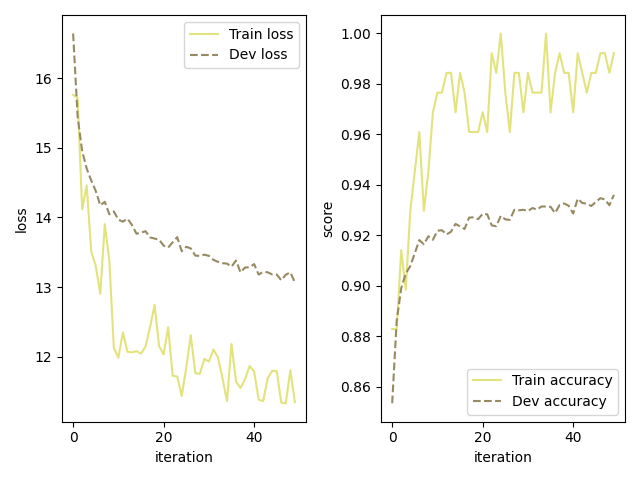

训练模型时验证准确率达到了0.936，测试准确率为0.8292。且根据图像观测，过拟合现象明显减弱，说明采用正则化技术对模型的泛化能力有所提升。

### 4. Implement the cross entropy loss. And incorporate a softmax (multinomial logistic) layer at the end of the network so that the 10 outputs can be interpreted as probabilities of each class.

`op.py`文件里的 MultiCrossEntropyLoss 类中实现了多分类交叉熵损失以及在网络末尾集成 Softmax 层。其中softmax函数的计算方式为：$p(y_i)=\frac{\exp(z_i)}{\sum_{j = 1}^{J}\exp(z_j)}$。

`softmax(X)`实现 Softmax 层，当 has_softmax 为 True 时，调用 softmax 函数对模型的输出 predicts 进行处理，将其转换为概率分布。

In [ ]:
def softmax(X):
    x_max = np.max(X, axis=1, keepdims=True)
    x_exp = np.exp(np.clip(X - x_max, -100, 100))
    partition = np.sum(x_exp, axis=1, keepdims=True)
    return x_exp / (partition + 1e-12)

`backward(self)`反向传播方法根据 has_softmax 的值，计算不同的梯度。当 has_softmax 为 True 时，使用 Softmax 层的梯度计算公式；当 has_softmax 为 False 时，使用不包含 Softmax 层的梯度计算公式。将计算得到的梯度 self.grads 传递给模型的 backward 方法，进行反向传播。

In [ ]:
def backward(self):
    batch_size = self.probs.shape[0]

    if self.has_softmax:
        one_hot = np.zeros_like(self.probs)
        one_hot[np.arange(batch_size), self.labels] = 1
        self.grads = (self.probs - one_hot) / batch_size
    else:
        self.grads = np.zeros_like(self.probs)
        correct_probs = self.probs[np.arange(batch_size), self.labels]
        self.grads[np.arange(batch_size), self.labels] = - \
            1.0 / (correct_probs * batch_size)

    self.model.backward(self.grads)

调整参数为：n_hidden=[256, 128]，learning_rate=0.001，use_nesterov=True，momentum=0.9，lr_milestones=[15, 20, 25, 30, 35, 40, 45]，weight_decay_lambda = 0.0001，dropout_rates=[0.01, 0.01]，loss_type="cross_entropy_with_l2"。用`test_train.py`对模型进行训练，再用`test_model.py`进行模型的测试。训练结果保存于 './best_models/best_model_4'，训练过程保存于 './training_logs/training_log_4'。

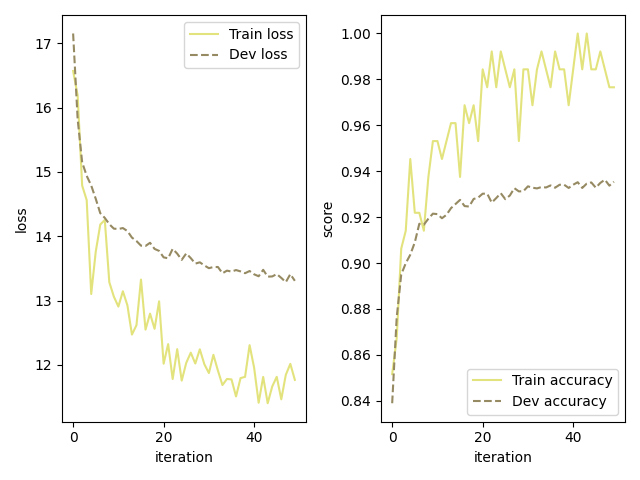

训练模型时验证准确率达到了0.9363，测试准确率为0.8309。模型效果有了轻微提升。

### 5. Implement the Conv2D operator on your own. And modify your Multi-Layer Perceptron into a CNN.

#### (1) Conv2D Operator

在`op.py`中 Conv2D 类实现了自定义的二维卷积算子。

`__init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0)`初始化卷积核权重 W 和偏置 b，存储梯度信息 grads 和输入信息 input。

In [ ]:
def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
    super().__init__()
    self.in_channels = in_channels
    self.out_channels = out_channels
    self.kernel_size = kernel_size if isinstance(
        kernel_size, tuple) else (kernel_size, kernel_size)
    self.stride = stride
    self.padding = padding

    scale = np.sqrt(
        2.0 / (in_channels * self.kernel_size[0] * self.kernel_size[1]))
    self.W = np.random.normal(0, scale, size=(
        out_channels, in_channels, self.kernel_size[0], self.kernel_size[1]))
    self.b = np.zeros(out_channels)

    self.grads = {'W': None, 'b': None}
    self.input = None
    self.params = {'W': self.W, 'b': self.b}
    self.weight_decay = False
    self.weight_decay_lambda = 0.0

`forward(self, X)`实现前向传播，计算输出特征图的高度 new_H 和宽度 new_W，根据填充情况对输入进行填充，遍历每个样本、每个输出通道、每个输出位置，计算卷积结果。

In [ ]:
def forward(self, X):
    self.input = X
    batch_size, _, H, W = X.shape

    new_H = (H + 2*self.padding - self.kernel_size[0]) // self.stride + 1
    new_W = (W + 2*self.padding - self.kernel_size[1]) // self.stride + 1

    if self.padding > 0:
        X_pad = np.pad(X, ((0, 0), (0, 0), (self.padding, self.padding),
                       (self.padding, self.padding)), mode='constant')
    else:
        X_pad = X

    output = np.zeros((batch_size, self.out_channels, new_H, new_W))

    for b in range(batch_size):
        for c_out in range(self.out_channels):
            for h in range(new_H):
                for w in range(new_W):
                    h_start = h * self.stride
                    w_start = w * self.stride
                    receptive_field = X_pad[b, :, h_start:h_start +
                                            self.kernel_size[0], w_start:w_start+self.kernel_size[1]]
                    output[b, c_out, h, w] = np.sum(
                        receptive_field * self.W[c_out]) + self.b[c_out]

    return output

`forward(self, X)`实现反向传播，初始化权重梯度 grads['W']、偏置梯度 grads['b'] 和输入梯度 input_grad，根据填充情况对输入和输入梯度进行填充，遍历每个样本、每个输出通道、每个输出位置，计算权重梯度、偏置梯度和输入梯度。

In [ ]:
def forward(self, X):
    self.input = X
    batch_size, _, H, W = X.shape

    new_H = (H + 2*self.padding - self.kernel_size[0]) // self.stride + 1
    new_W = (W + 2*self.padding - self.kernel_size[1]) // self.stride + 1

    if self.padding > 0:
        X_pad = np.pad(X, ((0, 0), (0, 0), (self.padding, self.padding),
                       (self.padding, self.padding)), mode='constant')
    else:
        X_pad = X

    output = np.zeros((batch_size, self.out_channels, new_H, new_W))

    for b in range(batch_size):
        for c_out in range(self.out_channels):
            for h in range(new_H):
                for w in range(new_W):
                    h_start = h * self.stride
                    w_start = w * self.stride
                    receptive_field = X_pad[b, :, h_start:h_start +
                                            self.kernel_size[0], w_start:w_start+self.kernel_size[1]]
                    output[b, c_out, h, w] = np.sum(
                        receptive_field * self.W[c_out]) + self.b[c_out]

    return output

#### (2) 卷积神经网络(CNN)：

在`models.py`文件中实现 Model_CNN 类，用于构建一个简单的卷积神经网络模型。

`__init__(self)`在初始化过程中，定义了模型的各层结构，并筛选出可优化的层（即具有梯度的层）。

In [ ]:
def __init__(self):
    super().__init__()
    self.layers = [
        Conv2D(in_channels=1, out_channels=16,
               kernel_size=3, padding=1),
        ReLU(),
        MaxPool2D(kernel_size=2),
        Conv2D(in_channels=16, out_channels=32,
               kernel_size=3, padding=1),
        ReLU(),
        MaxPool2D(kernel_size=2),
        Flatten(),
        Linear(in_dim=32*7*7, out_dim=128),
        ReLU(),
        Linear(in_dim=128, out_dim=10)
    ]
    self.optimizable_layers = [
        layer for layer in self.layers if hasattr(layer, 'grads')]

`__call__(self, X)`使得可以直接调用模型实例进行前向传播。

In [ ]:
def __call__(self, X):
    return self.forward(X)

`forward(self, X)`实现前向传播，首先对输入数据的形状进行检查和调整，确保其符合模型的输入要求。然后依次将数据通过模型的各层，最终得到输出结果。

In [ ]:
def forward(self, X):
    if len(X.shape) == 2:
        X = X.reshape(-1, 1, 28, 28)
    elif len(X.shape) == 3:
        X = X[:, np.newaxis, :, :]

    for layer in self.layers:
        X = layer(X)
    return X

`backward(self, grad)`实现反向传播，从最后一层开始，依次调用各层的 backward 方法，将梯度反向传播回去，计算各层的参数梯度。

In [ ]:
def backward(self, grad):
    for layer in reversed(self.layers):
        grad = layer.backward(grad)
    return grad

`save_model(self, save_path)`实现模型保存，将可优化层（卷积层和全连接层）的权重和偏置参数保存到文件中。


In [ ]:
def save_model(self, save_path):
    params = []
    for layer in self.optimizable_layers:
        if isinstance(layer, (Conv2D, Linear)):
            params.append({'W': layer.W, 'b': layer.b})
    with open(save_path, 'wb') as f:
        pickle.dump(params, f)

`load_model(self, param_list)`实现模型加载，从文件中读取保存的参数，并将其赋值给相应的可优化层。

In [ ]:
def load_model(self, param_list):
    with open(param_list, 'rb') as f:
        params = pickle.load(f)
    param_idx = 0
    for layer in self.optimizable_layers:
        if isinstance(layer, (Conv2D, Linear)):
            layer.W = params[param_idx]['W']
            layer.b = params[param_idx]['b']
            param_idx += 1

#### (3) 改进模型训练

选择CNN模型，调整参数为：learning_rate=0.001，use_nesterov=True，momentum=0.95，lr_milestones=[15, 30]，weight_decay_lambda = 0.00001，dropout_rates=[0.3, 0.3]，loss_type="cross_entropy"。用`cnn_train.py`对模型进行训练，再用`test_model.py`进行模型的测试。训练结果保存于 './best_models/best_model_cnn'，训练过程保存于 './training_logs/training_log_cnn'。

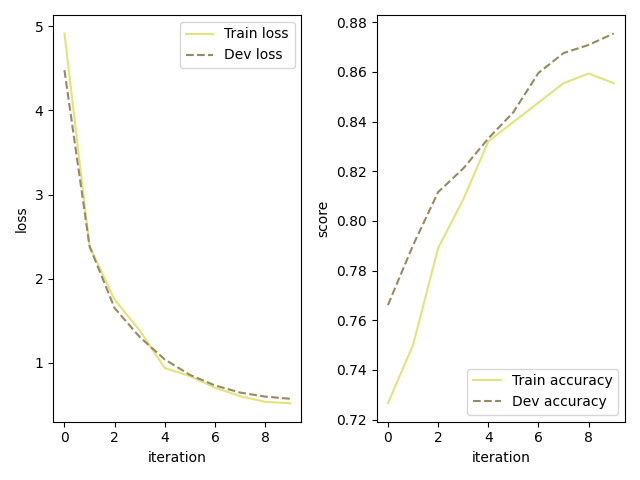

由于实验所需时间过长，我们仅训练了一个CNN模型，训练准确率为0.8755，有较高提升空间。

### 6. You can artificially create more training examples, by applying small transformations (translations, rotations, resizing, etc.) to the original images.

通过`runner.py`里的 ImageAugmenter 类来完成对原始图像应用小变换（平移、旋转、缩放等）以人工创建更多训练样本的任务。

`__init__(self, augmentations=None)`初始化时接收一个增强函数列表 augmentations 作为参数，若未提供 augmentations，则默认使用 random_shift、random_rotation、random_zoom 和 random_noise 这四个增强函数。

In [ ]:
def __init__(self, augmentations=None):
    self.augmentations = augmentations or [
        self.random_shift,
        self.random_rotation,
        self.random_zoom,
        self.random_noise
    ]

`__call__(self, images)`方法用于对批量图像应用增强操作，若输入图像为二维数组（扁平图像，适用于多层感知机），则先将其重塑为四维数组（[batch_size, height, width, channels]），对每个图像调用 _augment_single 方法进行增强操作。

In [ ]:
def __call__(self, images):
    if len(images.shape) == 2:  
        orig_shape = images.shape
        images = images.reshape(-1, 28, 28, 1)
        augmented = np.array([self._augment_single(img) for img in images])
        return augmented.reshape(orig_shape)
    else:  
        return np.array([self._augment_single(img) for img in images])

`_augment_single(self, image)`方法用于对单张图像应用随机增强操作，随机选择一些增强函数，这些函数的数量也是随机的，依次对图像应用这些随机选择的增强函数。

In [ ]:
def _augment_single(self, image):
    aug_fns = np.random.choice(
        self.augmentations,
        size=np.random.randint(0, len(self.augmentations)+1),
        replace=False
    )
    result = image.copy()
    for fn in aug_fns:
        result = fn(result)
    return result

`random_shift(self, image, max_shift=2)`随机平移函数随机生成水平和垂直方向的平移量 dx 和 dy，创建平移矩阵 M，使用 cv2.warpAffine 函数对图像进行平移操作。

In [ ]:
def random_shift(self, image, max_shift=2):
    h, w, c = image.shape
    dx, dy = np.random.randint(-max_shift, max_shift+1, size=2)
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    shifted = np.zeros_like(image)
    for i in range(c):
        shifted[:, :, i] = cv2.warpAffine(image[:, :, i], M, (w, h))
    return shifted

`random_rotation(self, image, max_angle=15)`随机旋转函数随机生成旋转角度 angle，获取旋转矩阵 M，使用 cv2.warpAffine 函数对图像进行旋转操作。

In [ ]:
def random_rotation(self, image, max_angle=15):
    h, w, c = image.shape
    angle = np.random.uniform(-max_angle, max_angle)
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
    rotated = np.zeros_like(image)
    for i in range(c):
        rotated[:, :, i] = cv2.warpAffine(image[:, :, i], M, (w, h))
    return rotated

In [ ]:
def random_zoom(self, image, scale_range=(0.9, 1.1)):
    h, w, c = image.shape
    scale = np.random.uniform(*scale_range)
    new_h, new_w = int(h * scale), int(w * scale)
    zoomed = np.zeros_like(image)
    for i in range(c):
        channel = cv2.resize(image[:, :, i], (new_w, new_h))
        if scale > 1: 
            start_h = (new_h - h) // 2
            start_w = (new_w - w) // 2
            zoomed[:, :, i] = channel[start_h:start_h+h, start_w:start_w+w]
        else:
            start_h = (h - new_h) // 2
            start_w = (w - new_w) // 2
            zoomed[start_h:start_h+new_h, start_w:start_w+new_w, i] = channel

    return zoomed